## Wright-Fisher Genetic Drift Simulation
# Overview

This project uses Python to simulate genetic drift in a finite diploid population using the Wright-Fisher model.

The simulation follows the frequency of a mutation across generations under random binomial sampling, allowing the mutation to eventually become fixed or be lost from the population. In each generation, the number of mutant allele copies is sampled from a binomial distribution, allowing the mutation frequency to change randomly through genetic drift.

The analysis explores:

- how allele frequencies change over generations due to genetic drift;
- variation in frequency trajectories across independent simulations;
- the probability that a mutation becomes fixed; and
- how simulated fixation probabilities compare with theoretical expectations.

The simulations use a population size of N = 100 diploid individuals and consider different starting mutation frequencies.


### Tools

- Python
- NumPy
- Matplotlib
- Probability and stochastic simulation
- Population genetics
- Wright-Fisher model

## Model

The Wright-Fisher model describes allele-frequency change in a finite population under random sampling.

For a diploid population of N individuals, there are 2N copies of an allele. Given an allele frequency p in the current generation, the number of copies in the next generation is sampled from:

$$
k \sim \text{Binomial}(2N,p)
$$

The allele frequency in the next generation is then:

$$
p' = \frac{k}{2N}
$$

The simulation continues until the allele is either lost from the population ($p = 0$) or becomes fixed ($p = 1$).

Because the sampling process is random, repeated simulations can produce different allele-frequency trajectories even when they start from the same initial frequency.


## 1. Simulating Genetic Drift

I first simulated the trajectory of a mutation beginning at a frequency of p = 0.5 in a diploid population of N = 100 individuals.

The simulation was continued until the mutation was either lost or fixed. A random seed was used to make the simulation reproducible.

In [20]:
import numpy as np

# Population size
N = 100
# Initial mutation frequency
p = 0.5

# Set random seed for reproducibility
np.random.seed(42)

# Starting generation
generation = 0

# Run the Wright-Fisher simulation
while p > 0 and p < 1:
    generation += 1
    
    # Sample number of mutant alleles
    k = np.random.binomial(2 * N, p)
    
    # Update frequency
    p = k / (2 * N)
    
    # Print every 20 generations
    if generation % 20 == 0:
        print(f"Generation {generation}: p = {p:.4f}")

# Print final result
if p == 1:
    print(f"\nMutation became fixed at generation {generation}.")
else:
    print(f"\nMutation was lost at generation {generation}.")


Generation 20: p = 0.3250
Generation 40: p = 0.2900
Generation 60: p = 0.4800
Generation 80: p = 0.1850
Generation 100: p = 0.2500
Generation 120: p = 0.1050
Generation 140: p = 0.0600

Mutation was lost at generation 146.


### Interpretation

Starting from a frequency of 0.5, the mutation eventually became lost after 146 generations.

This illustrates genetic drift: even without selection, mutation frequency can change substantially between generations because individuals are sampled randomly to form the next generation.

## 2. Genetic Drift Across Multiple Simulations

I next repeated the simulation five times from the same starting frequency of p = 0.5 and stored the allele-frequency trajectory of each simulation.

Although all simulations began with the same population size and starting frequency, the trajectories differed because each generation involves random binomial sampling.

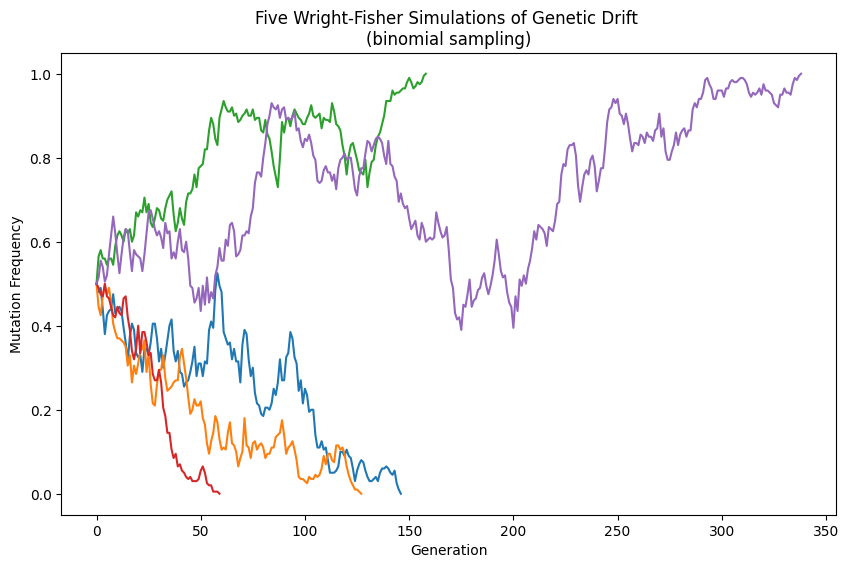

In [ ]:
import matplotlib.pyplot as plt

np.random.seed(42)

#five generations of genetic drift simulations

N = 100
num_simulations = 5
plt.figure(figsize=(10, 6))

for sim in range(num_simulations):
    p = 0.5  # Starting frequency
    freqs = [p]  # Store initial frequency
    generation = 0

# Run until fixation or loss
    while p > 0 and p < 1:
        generation += 1
        k = np.random.binomial(2 * N, p)
        p = k / (2 * N)
        freqs.append(p)
    
# Plot the trajectory
    plt.plot(range(len(freqs)), freqs, label=f"Run {sim + 1}")


plt.title("Five Wright-Fisher Simulations of Genetic Drift \n(binomial sampling)")
plt.xlabel("Generation")
plt.ylabel("Mutation Frequency")
plt.show()

### Interpretation

The five simulations produce different allele-frequency trajectories even though they have identical starting conditions.

Some trajectories may reach fixation, while others may reach loss. This variation is an expected consequence of genetic drift and demonstrates the stochastic nature of the Wright-Fisher model.

The effect of random sampling is particularly important in finite populations because chance events can substantially alter allele frequencies over time.

## 3. Estimating Fixation Probability

I then estimated the probability that a mutation becomes fixed for two different starting frequencies:

- p = 0.5
- p = 1/(2N) = 0.005

For each starting frequency, simulations were repeated until 100 fixation events had been observed. The estimated fixation probability was calculated as:

$$
P(\text{fixation}) =
\frac{\text{number of fixations}}
{\text{number of simulations}}
$$

Under the neutral Wright-Fisher model, the theoretical probability of fixation is equal to the initial allele frequency:

$$
P(\text{fixation}) = p_0
$$

In [19]:
np.random.seed(42)

N = 100
starting_ps = [0.5, 1 / (2 * N)]

for p0 in starting_ps:
    number_of_runs = 0
    number_of_fixations = 0

    # Run simulations until 100 fixations are observed
    while number_of_fixations < 100:
        p = p0

        # Simulate until fixation or loss
        while p > 0 and p < 1:
            k = np.random.binomial(2 * N, p)
            p = k / (2 * N)

        number_of_runs += 1

        if p == 1:
            number_of_fixations += 1

    fixation_prob = number_of_fixations / number_of_runs

    print(
        f"Starting p = {p0:.4f} → "
        f"Estimated fixation probability = {fixation_prob:.4f} "
        f"({number_of_runs} simulations)"
    )

Starting p = 0.5000 → Estimated fixation probability = 0.4717 (212 simulations)
Starting p = 0.0050 → Estimated fixation probability = 0.0053 (18910 simulations)


### Results

For a starting frequency of p = 0.5, the theoretical fixation probability is 0.5. The simulation produced an estimated fixation probability of approximately 0.4717.

For a starting frequency of p = 0.005, corresponding to a single copy of the mutation in a population of 100 diploid individuals, the theoretical fixation probability is 0.005. The simulation produced an estimated fixation probability of approximately 0.0053.

The simulated estimates were broadly consistent with the theoretical expectations, although some difference is expected because the estimates are based on a finite number of stochastic simulations.

## 4. Conclusion

This project used the Wright-Fisher model to simulate genetic drift in a finite diploid population.

The simulations demonstrated that allele frequencies can change substantially through random sampling alone, with mutations potentially becoming fixed or being lost from the population.

Repeated simulations produced different frequency trajectories despite identical starting conditions, highlighting the stochastic nature of genetic drift.

The estimated fixation probabilities were also broadly consistent with the theoretical prediction that, under a neutral Wright-Fisher model, the probability of fixation of an allele is equal to its initial frequency.

### Key Skills Demonstrated

- Implementing stochastic population-genetic simulations in Python
- NumPy random sampling and binomial distributions
- Modelling allele-frequency trajectories
- Monte Carlo simulation
- Data visualisation with Matplotlib
- Comparing simulations with theoretical expectations
- Interpreting genetic drift and fixation probability

## Academic Context

This project was completed as part of Computational Biology coursework at Cornell University.

The repository presents my implementation, analysis and interpretation as part of my personal computational biology portfolio.